In [1]:
from utils.consts import * ## const variables are there, so paths and extraction features ##
from utils. plotting import * ## plotting ##
from data_reader_babalit import * ## the class which reads balabit dataset ##
from data_reader_chaoshen import * ## the class which reads chaoshen datasets TODO There are several issues with this dataset -> explained later ##
from legality_analyser import * ## the class which analyses the datasets with 0 1 labels --> splitting samples is being done there ##  
import random


In [8]:
users = [7,9,15,16,20,21,23,29, 35]
balabit_reader = DataReaderBalabit(BALABIT, users, True, limit = 1000) ## the arguments are DATASET, users, supervised, how many records should be procesed ##



In [2]:
from RandomForestModel import *
from nonlegality_analyser import * ## the class which analyses the datasets without 0 1 labels --> splitting samples is being done there ##  


In [3]:
## Specyfing the USERS ## 
users = [7,9,15,16,20,21,23,29, 35]
## Creating the object which analyses the dataset ## 
balabit_reader = DataReaderBalabit(BALABIT, users, False, limit = 100) ## the arguments are DATASET, users, supervised, how many records should be procesed ##
balabit_reader.processDataWithoutLabels() ## creating the data without labels ##


processed_files\balabit_dataset_users[7, 9, 15, 16, 20, 21, 23, 29, 35]_limit100_labelsFalse.csv
True
File already exist


In [6]:
balabit_reader.setSupervised(True)
balabit_reader.processDataWithLabels(25)

ValueError: LegalUser doesnt exist

In [12]:
## getting path from the reader ## 
path = balabit_reader.getFile()
## creating analyser class ## 
balabitAnalyser = nonLegalityAnalyser(path)
## counting how many actions were extracted ## 
print(balabitAnalyser.countActions())

type_of_action    1   3   4
userid                     
7                65  88   4
9                72  76   8
15               40  65   8
16               88  64  16
20              137  89   6
21               57  58  10
23               45  69   3
29               33  71   7
35               60  64   2


In [13]:
from OneClassSVMModel import *

In [14]:
fpr = {}
tpr = {}
roc_auc = {}
shuffle = True
for legalUser in users:
    dataset = balabitAnalyser.createTrainingDataWithLabel(legalUser)
    X = dataset[:, 0:-1]
    y = dataset[:, -1]
    X_train, X_validation, y_train, y_validation = balabitAnalyser.trainingTestSplit(X, y, TEST_SIZE, shuffle)
    y_validation = np.where(y_validation == 0, -1, y_validation)

    model = OneClassSVMModel(dataset, users)
    fpr[legalUser], tpr[legalUser], thr = model.evaluate(X_train, y_train, X_validation, y_validation, legalUser)
    threshold = -1
    try:
        eer = brentq(lambda x: 1. - x - interp1d(fpr[legalUser], tpr[legalUser])(x), 0., 1.) ## brentq znajdowanie 0 , interpid interpolacja 
        threshold = interp1d(fpr[legalUser], thr)(eer)

    except (ZeroDivisionError, ValueError):
        print("Division by zero")

    roc_auc[legalUser] = auc(fpr[legalUser], tpr[legalUser])
    print(str(legalUser) + ": " + str(roc_auc[legalUser])+" threshold: "+str(threshold))

plotROCs(fpr, tpr, roc_auc, users)

User 7 is being analyzed:


ValueError: Found array with 0 sample(s) (shape=(0, 40)) while a minimum of 1 is required by StandardScaler.

In [ ]:
from IsolationForestModel import *

User 7 is being analyzed:
Test Accuracy: 0.53
7: 0.5954993322986971 threshold: 0.07301226969934982
User 9 is being analyzed:
Test Accuracy: 0.59
9: 0.7172848564239989 threshold: 0.05633797478944444
User 15 is being analyzed:
Test Accuracy: 0.54
15: 0.6441161874178952 threshold: 0.06487643656957809
User 16 is being analyzed:
Test Accuracy: 0.52
16: 0.6407202018278751 threshold: 0.08964866769445723
User 20 is being analyzed:
Test Accuracy: 0.49
20: 0.4161450594957051 threshold: 0.0818626928712946
User 21 is being analyzed:
Test Accuracy: 0.55
21: 0.7196720466147579 threshold: 0.0555133847673759
User 23 is being analyzed:
Test Accuracy: 0.61
23: 0.8281038535508227 threshold: 0.055826942433276426
User 29 is being analyzed:
Test Accuracy: 0.50
29: 0.5528159049101458 threshold: 0.07966849747046836
User 35 is being analyzed:
Test Accuracy: 0.55
35: 0.7994435427776491 threshold: 0.07414367528174108


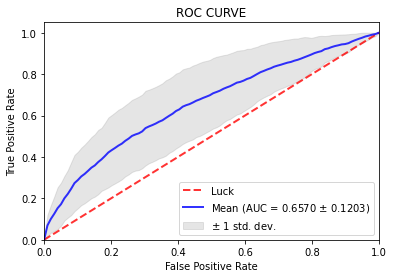

In [ ]:
fpr = {}
tpr = {}
roc_auc = {}
shuffle = True
for legalUser in users:
    dataset = balabitAnalyser.createTrainingDataWithLabel(legalUser)
    X = dataset[:, 0:-1]
    y = dataset[:, -1]
    X_train, X_validation, y_train, y_validation = balabitAnalyser.trainingTestSplit(X, y, TEST_SIZE, shuffle)
    y_validation = np.where(y_validation == 0, -1, y_validation)

    model = IsolationForestModel(dataset, users)
    fpr[legalUser], tpr[legalUser], thr = model.evaluate(X_train, y_train, X_validation, y_validation, legalUser)
    threshold = -1
    try:
        eer = brentq(lambda x: 1. - x - interp1d(fpr[legalUser], tpr[legalUser])(x), 0., 1.) ## brentq znajdowanie 0 , interpid interpolacja 
        threshold = interp1d(fpr[legalUser], thr)(eer)

    except (ZeroDivisionError, ValueError):
        print("Division by zero")

    roc_auc[legalUser] = auc(fpr[legalUser], tpr[legalUser])
    print(str(legalUser) + ": " + str(roc_auc[legalUser])+" threshold: "+str(threshold))

plotROCs(fpr, tpr, roc_auc, users)

In [ ]:
from utils.consts import *
from utils. plotting import *
from data_reader_chaoshen import *
from nonlegality_analyser import *
import random

In [ ]:
users = [1,2, 3, 5, 4,16,20,21,23]
chaoshen_reader = DataReaderChaoShen(CHAOSHEN, users, limit = 500)
chaoshen_reader.processDataWithoutLabels()

In [ ]:
from utils.consts import *
from utils. plotting import *
from data_reader_singapur import *
from nonlegality_analyser import *

In [ ]:
users = [1,2, 3, 4, 5, 6,9, 7, 16,20,21,23]

singapur_reader = DataReaderSingapur(SINGAPUR, users)


In [ ]:
singapur_reader.processDataWithoutLabels()